Business question: Which lifecycle stage generates the most value, and how does AOV change with maturity?

This shows not just the average value per lifecycle stage, but the distribution of value. A wide violin means unpredictable revenue; a narrow one means consistency. 

In [1]:
# ── 00. SETUP ────────────────────────────────────────────────────────
# Paste this block at the top of every visualization notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── 1. GLOBAL STYLE ──────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

FIGSIZE_STD   = (12, 5)   # standard wide chart
FIGSIZE_TALL  = (10, 7)   # for scatter / complex plots
FIGSIZE_PANEL = (14, 6)   # side-by-side panels
DPI           = 130

# Colour palette — consistent across all charts
PALETTE = {
    'churn_high': '#f85149',   # red  — high churn risk
    'churn_low':  '#3fb950',   # green — loyal customers
    'neutral':    '#58a6ff',   # blue  — general insight
    'accent':     '#e3b341',   # gold  — highlight
    'purple':     '#bc8cff',   # purple — secondary
}

# ── 2. LOAD DATA ─────────────────────────────────────────────────────
df = pd.read_csv('../data/customer_churn.csv')

# ── 3. DATE ENGINEERING ──────────────────────────────────────────────
df['Launch_Date']    = pd.to_datetime(df['Launch_Date'])
df['Peak_Sales_Date'] = pd.to_datetime(df['Peak_Sales_Date'])

# How many days from launch to peak performance
df['Days_to_Peak'] = (
    df['Peak_Sales_Date'] - df['Launch_Date']
).dt.days

# How long the product has been live (vs a reference "today")
REFERENCE_DATE = pd.Timestamp('2024-01-01')
df['Product_Age_Days'] = (
    REFERENCE_DATE - df['Launch_Date']
).dt.days

df['Launch_Year']  = df['Launch_Date'].dt.year
df['Launch_Month'] = df['Launch_Date'].dt.month

# ── 4. LIFECYCLE STAGE ENGINEERING ───────────────────────────────────
# Bin customers by purchase frequency into lifecycle stages
df['Lifecycle_Stage'] = pd.cut(
    df['Purchase_Frequency'],
    bins=[0, 3, 7, 12, 20],
    labels=['New', 'Developing', 'Established', 'Loyal']
)

# ── 5. CHURN RISK BANDS ──────────────────────────────────────────────
df['Churn_Risk_Band'] = pd.cut(
    df['Churn_Probability'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# ── 6. ADOPTER TYPE ──────────────────────────────────────────────────
# Early adopters = customers who transacted within 6 months of launch
df['Adopter_Type'] = np.where(
    df['Launch_Year'] <= 2021,
    'Early Adopter',
    'Later User'
)

# ── 7. CUSTOMER MATURITY BAND ────────────────────────────────────────
df['Maturity_Band'] = pd.cut(
    df['Lifetime_Value'],
    bins=[0, 2000, 5000, 10000],
    labels=['Early Value', 'Growth Value', 'Mature Value']
)

# ── 8. OUTPUT FOLDER ─────────────────────────────────────────────────
OUT = Path('../outputs/charts')
OUT.mkdir(parents=True, exist_ok=True)

print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"✓ Output path: {OUT}")
df.head(3)

✓ Dataset loaded: 10,000 rows × 23 cols
✓ Output path: ..\outputs\charts


,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,...,Preferred_Purchase_Times,Retention_Strategy,Days_to_Peak,Product_Age_Days,Launch_Year,Launch_Month,Lifecycle_Stage,Churn_Risk_Band,Adopter_Type,Maturity_Band
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,...,Afternoon,Loyalty Program,1276,1388,2020,3,Loyal,High Risk,Early Adopter,Early Value
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,...,Afternoon,Discount,79,443,2022,10,Established,Medium Risk,Later User,Mature Value
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,...,Evening,Loyalty Program,492,762,2021,11,New,Medium Risk,Early Adopter,Growth Value


C:\Users\Admin\AppData\Local\Temp\ipykernel_15592\975700516.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


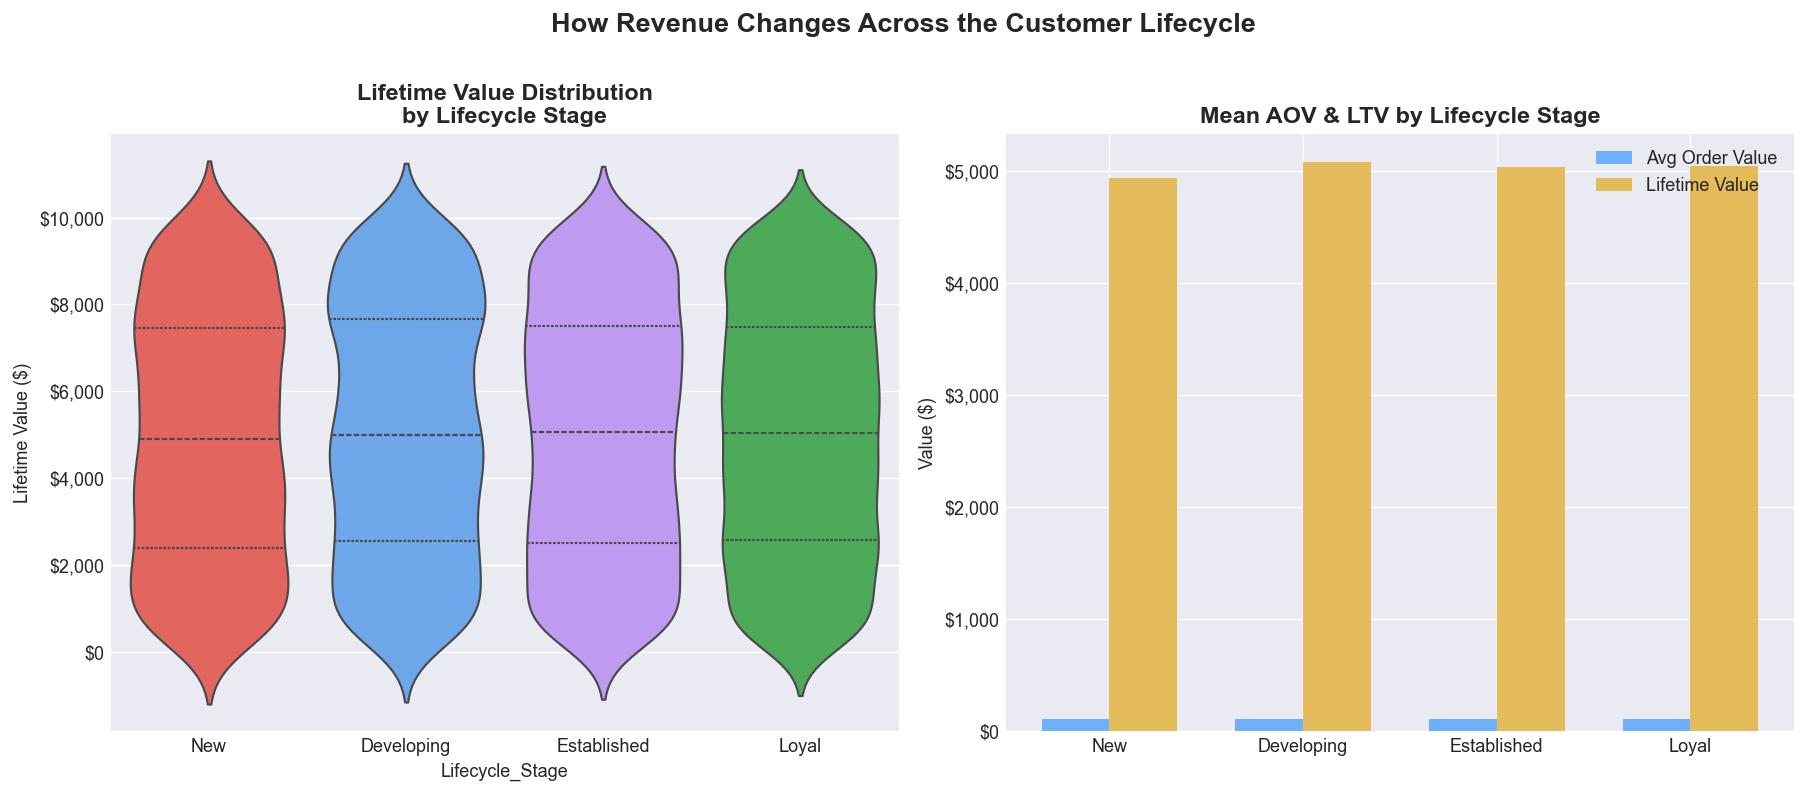

In [2]:
# ── 03. LIFECYCLE STAGE vs REVENUE ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PANEL, dpi=DPI)
order = ['New', 'Developing', 'Established', 'Loyal']
colors = [PALETTE['churn_high'], PALETTE['neutral'],
           PALETTE['purple'], PALETTE['churn_low']]

# LEFT: Violin — Lifetime Value distribution
sns.violinplot(
    data=df, x='Lifecycle_Stage', y='Lifetime_Value',
    order=order, palette=colors,
    inner='quartile', linewidth=1.2, ax=axes[0]
)
axes[0].set_title('Lifetime Value Distribution\nby Lifecycle Stage',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Lifetime Value ($)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# RIGHT: Grouped bar — mean AOV + mean LTV side by side
stage_summary = (
    df.groupby('Lifecycle_Stage', observed=True)
      [['Average_Order_Value', 'Lifetime_Value']]
      .mean().reindex(order)
)
x = np.arange(len(order))
w = 0.35

axes[1].bar(x-w/2, stage_summary['Average_Order_Value'],
           w, label='Avg Order Value',
           color=PALETTE['neutral'], alpha=0.85)
axes[1].bar(x+w/2, stage_summary['Lifetime_Value'],
           w, label='Lifetime Value',
           color=PALETTE['accent'], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(order)
axes[1].set_title('Mean AOV & LTV by Lifecycle Stage',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('How Revenue Changes Across the Customer Lifecycle',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / '03_lifecycle_revenue.png', bbox_inches='tight')
plt.show()